# Exploração GTFS - SPTrans

- *General Transit Feed Specification*
- Fonte dos dados: https://www.sptrans.com.br/desenvolvedores/ 
  - Documentação: https://gtfs.org/documentation/overview/

<figure style="text-align:center">
<img src="../images/MER-GTFS-SPTrans.png" width="100%">
<figcaption>
Modelo Entidade-Relacionamento do GTFS da SPTrans - Willy Paulino de Oliveira Gomes
</figcaption>
</figure>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path


REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'gtfs'

# print(f"Raiz do repo: {REPO_ROOT}")
# print(f"Dados GTFS:   {DATA_PATH}")
# print(f"Existe?       {DATA_PATH.exists()}")

In [2]:
arquivos_gtfs = [
    'agency',
    'calendar',
    'fare_attributes',
    'fare_rules',
    'frequencies',
    'routes',
    'shapes',
    'stop_times',
    'stops',
    'trips'
]

gtfs = {}
for arquivo in arquivos_gtfs:
    caminho = DATA_PATH / f'{arquivo}.txt'
    gtfs[arquivo] = pd.read_csv(caminho)
    n_linhas, n_colunas = gtfs[arquivo].shape
    print(f" {arquivo:<20} {n_linhas:>10,} linhas | {n_colunas} colunas")

 agency                        1 linhas | 5 colunas
 calendar                      6 linhas | 10 colunas
 fare_attributes               6 linhas | 6 colunas
 fare_rules                5,379 linhas | 5 colunas
 frequencies              40,146 linhas | 4 colunas
 routes                    1,348 linhas | 7 colunas
 shapes                1,134,502 linhas | 5 colunas
 stop_times               98,434 linhas | 5 colunas
 stops                    22,103 linhas | 5 colunas
 trips                     2,254 linhas | 6 colunas


### Agency

In [3]:
print(gtfs['agency'].info())

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   agency_id        1 non-null      int64
 1   agency_name      1 non-null      str  
 2   agency_url       1 non-null      str  
 3   agency_timezone  1 non-null      str  
 4   agency_lang      1 non-null      str  
dtypes: int64(1), str(4)
memory usage: 172.0 bytes
None


In [4]:
print(gtfs['agency'])

   agency_id agency_name                                agency_url  \
0          1     SPTRANS  http://www.sptrans.com.br/?versao=080326   

     agency_timezone agency_lang  
0  America/Sao_Paulo          pt  


### Calendar

In [5]:
print(gtfs['calendar'].info())

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   service_id  6 non-null      str  
 1   monday      6 non-null      int64
 2   tuesday     6 non-null      int64
 3   wednesday   6 non-null      int64
 4   thursday    6 non-null      int64
 5   friday      6 non-null      int64
 6   saturday    6 non-null      int64
 7   sunday      6 non-null      int64
 8   start_date  6 non-null      int64
 9   end_date    6 non-null      int64
dtypes: int64(9), str(1)
memory usage: 612.0 bytes
None


In [6]:
print(gtfs['calendar'])

  service_id  monday  tuesday  wednesday  thursday  friday  saturday  sunday  \
0        USD       1        1          1         1       1         1       1   
1        U__       1        1          1         1       1         0       0   
2        US_       1        1          1         1       1         1       0   
3        _SD       0        0          0         0       0         1       1   
4        __D       0        0          0         0       0         0       1   
5        _S_       0        0          0         0       0         1       0   

   start_date  end_date  
0    20231001  20261001  
1    20231001  20261001  
2    20231001  20261001  
3    20231001  20261001  
4    20231001  20261001  
5    20231001  20261001  


#### service_id
- USD: opera todos os dias
- U__: opera somente nos dias úteis
- US_: opera de segunda a sábado
- _SD: opera somente aos sábados e domingos
- __D: opera somente aos domingos
- _S_: opera somente aos sábados

### Routes

In [7]:
print(gtfs['routes'].info())

<class 'pandas.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   route_id          1348 non-null   str  
 1   agency_id         1348 non-null   int64
 2   route_short_name  1348 non-null   str  
 3   route_long_name   1348 non-null   str  
 4   route_type        1348 non-null   int64
 5   route_color       1348 non-null   str  
 6   route_text_color  1339 non-null   str  
dtypes: int64(2), str(5)
memory usage: 73.8 KB
None


In [8]:
print(gtfs['routes'].head())

  route_id  agency_id route_short_name  \
0  1012-10          1          1012-10   
1  1012-21          1          1012-21   
2  1014-10          1          1014-10   
3  1015-10          1          1015-10   
4  1016-10          1          1016-10   

                             route_long_name  route_type route_color  \
0        Term. Jd. Britania - Jd. Monte Belo           3      509E2F   
1           Term. Jd. Britânia - Jd. Rosinha           3      509E2F   
2                    Cptm Perus - Morro Doce           3      509E2F   
3  Term. Jd. Britânia - Chác. Maria Trindade           3      509E2F   
4         Cem. Do Horto - Shop. Center Norte           3      002F6C   

  route_text_color  
0           FFFFFF  
1           FFFFFF  
2           FFFFFF  
3           FFFFFF  
4           FFFFFF  


In [9]:
print(gtfs['routes']['route_type'].value_counts())

route_type
3    1335
2       7
1       6
Name: count, dtype: int64


Referência: https://gtfs.org/documentation/schedule/reference/

route_type:
1 - Metrô
2 - Trem
**3 - Ônibus**

### Stops

In [10]:
print(gtfs['stops'].info())

<class 'pandas.DataFrame'>
RangeIndex: 22103 entries, 0 to 22102
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   stop_id    22103 non-null  int64  
 1   stop_name  22103 non-null  str    
 2   stop_desc  20684 non-null  str    
 3   stop_lat   22103 non-null  float64
 4   stop_lon   22103 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 863.5 KB
None


In [11]:
print(gtfs['stops'].head())

   stop_id      stop_name stop_desc   stop_lat   stop_lon
0    18848       Clínicas       NaN -23.554022 -46.671108
1    18849  Vila Madalena       NaN -23.546498 -46.691141
2    18850     Consolação       NaN -23.558094 -46.660205
3    18851      Conceição       NaN -23.635039 -46.641239
4    18852      Jabaquara       NaN -23.646033 -46.641028


In [12]:
s_linhas, s_colunas = gtfs['stops'].shape
print(f' Linhas/Estações: {s_linhas:,} | Colunas: {s_colunas}')

 Linhas/Estações: 22,103 | Colunas: 5


In [13]:
# valores nulos
print(gtfs['stops'].isnull().sum())

stop_id         0
stop_name       0
stop_desc    1419
stop_lat        0
stop_lon        0
dtype: int64


In [14]:
stops = gtfs['stops']
print(f'Latitude:  {stops.stop_lat.min():.4f} (sul) a {stops.stop_lat.max():.4f} (norte)')
print(f'Longitude: {stops.stop_lon.min():.4f} (oeste) a {stops.stop_lon.max():.4f} (leste)')

Latitude:  -23.9111 (sul) a -23.1956 (norte)
Longitude: -46.9839 (oeste) a -46.1849 (leste)


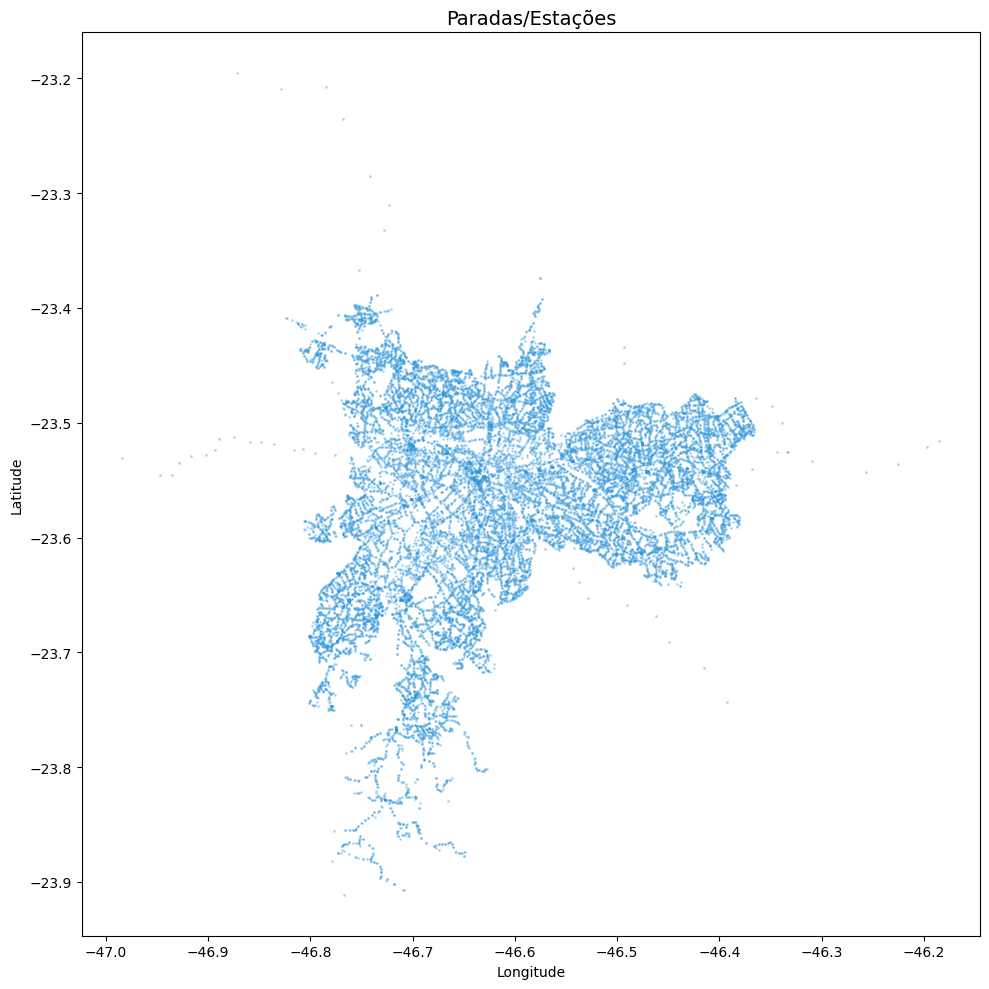

In [15]:
stops = gtfs['stops']

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    stops['stop_lon'],   # eixo X = longitude
    stops['stop_lat'],   # eixo Y = latitude
    s=1,
    alpha=0.3,
    color='#3498db'
)

ax.set_title('Paradas/Estações', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

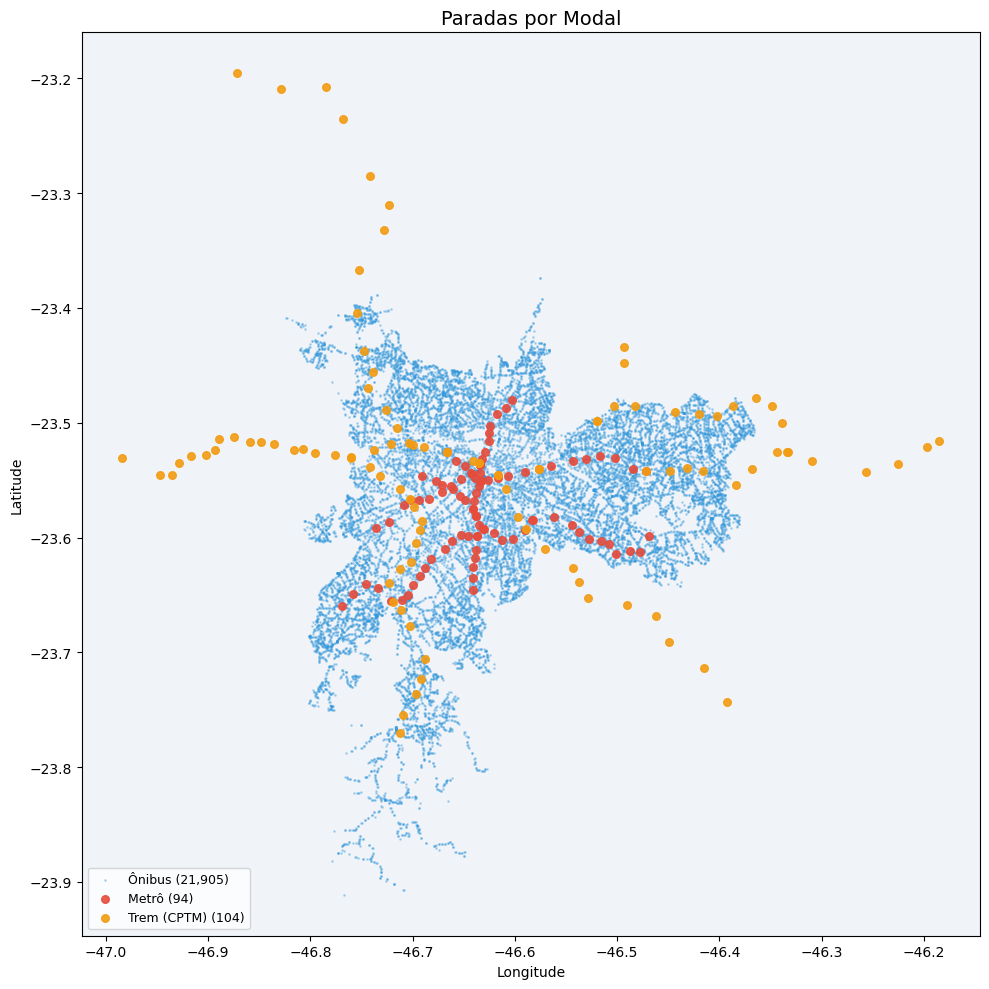

In [16]:
stops = gtfs['stops']
stop_times = gtfs['stop_times']
trips = gtfs['trips']
routes = gtfs['routes']

# Combinações únicas de (stop_id, trip_id) do stop_times
# drop_duplicates() remove repetições — só precisamos saber QUAIS trips passam em QUAIS paradas, não quantas vezes
stop_trip = stop_times[['stop_id', 'trip_id']].drop_duplicates()

# Adicionar route_id (de trips.txt)
stop_route = stop_trip.merge(trips[['trip_id', 'route_id']], on='trip_id')

# Adicionar route_type (de routes.txt)
stop_route = stop_route.merge(routes[['route_id', 'route_type']], on='route_id')

# Para cada parada, pegar o route_type predominante
# Uma parada pode ter ônibus E metrô passando. Usamos first() como simplificação.
# groupby('stop_id') agrupa todas as linhas com mesmo stop_id
stop_modal = stop_route.groupby('stop_id')['route_type'].first().reset_index()

# Juntar de volta com stops pra ter as coordenadas
stops_com_modal = stops.merge(stop_modal, on='stop_id', how='left')


fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('#f0f4f8')


cores = {3: '#3498db', 1: '#e74c3c', 2: '#f39c12'}
nomes = {3: 'Ônibus', 1: 'Metrô', 2: 'Trem (CPTM)'}

# Plotar cada modal separadamente pra controlar tamanho e legenda
for route_type in [3, 1, 2]:
    mask = stops_com_modal['route_type'] == route_type
    qtd = mask.sum()
    ax.scatter(
        stops_com_modal.loc[mask, 'stop_lon'],
        stops_com_modal.loc[mask, 'stop_lat'],
        s=1 if route_type == 3 else 30,       
        alpha=0.3 if route_type == 3 else 0.9, 
        color=cores[route_type],
        label=f"{nomes[route_type]} ({qtd:,})",
        zorder=2 if route_type == 3 else 3
    )

ax.set_title('Paradas por Modal', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=9, markerscale=1)

plt.tight_layout()
plt.show()

In [17]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [18]:
import geopandas as gpd

municipios = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'ibge' / 'SP_Municipios_2024.shp')

# colunas do shapefile
print("Colunas:", list(municipios.columns))
print()

Colunas: ['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG', 'CD_CONCU', 'NM_CONCU', 'AREA_KM2', 'geometry']



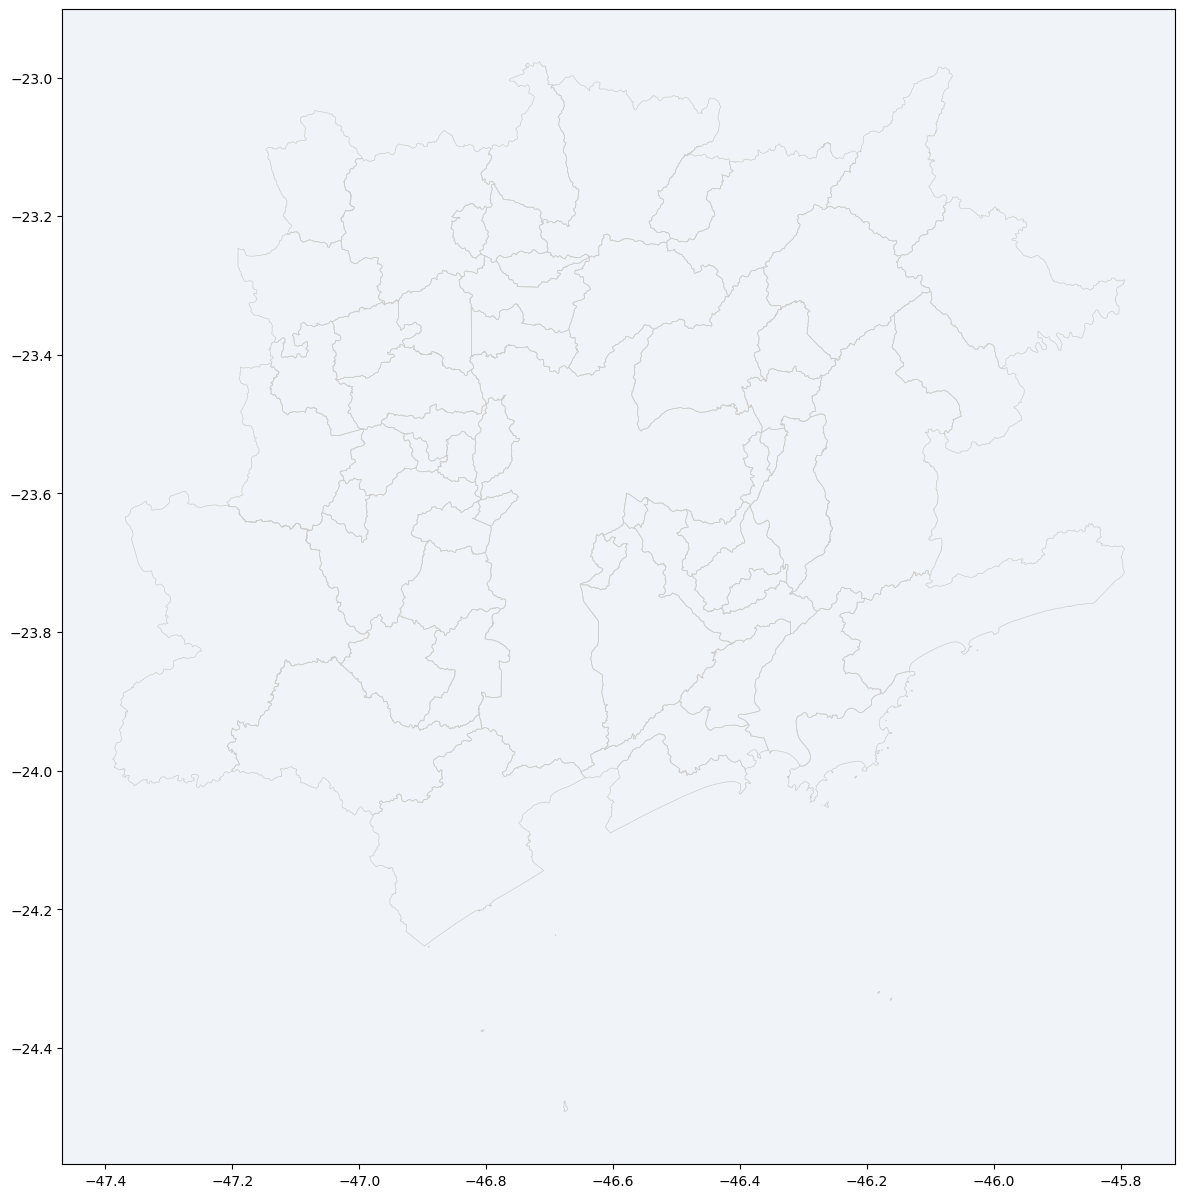

In [19]:
# Limites municipais
municipios = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'ibge' / 'SP_Municipios_2024.shp')

# Região Metropolitana de São Paulo (RMSP)
margem = 0.05
lon_min = stops_com_modal['stop_lon'].min() - margem
lon_max = stops_com_modal['stop_lon'].max() + margem
lat_min = stops_com_modal['stop_lat'].min() - margem
lat_max = stops_com_modal['stop_lat'].max() + margem

# cx (clip by extent) recorta os municípios que caem dentro dessa "caixa"
municipios_recorte = municipios.cx[lon_min:lon_max, lat_min:lat_max]


fig, ax = plt.subplots(figsize=(15, 15))
ax.set_facecolor('#f0f4f8')

municipios_recorte.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#cccccc',
    linewidth=0.5,
    zorder=1,
)

plt.show()

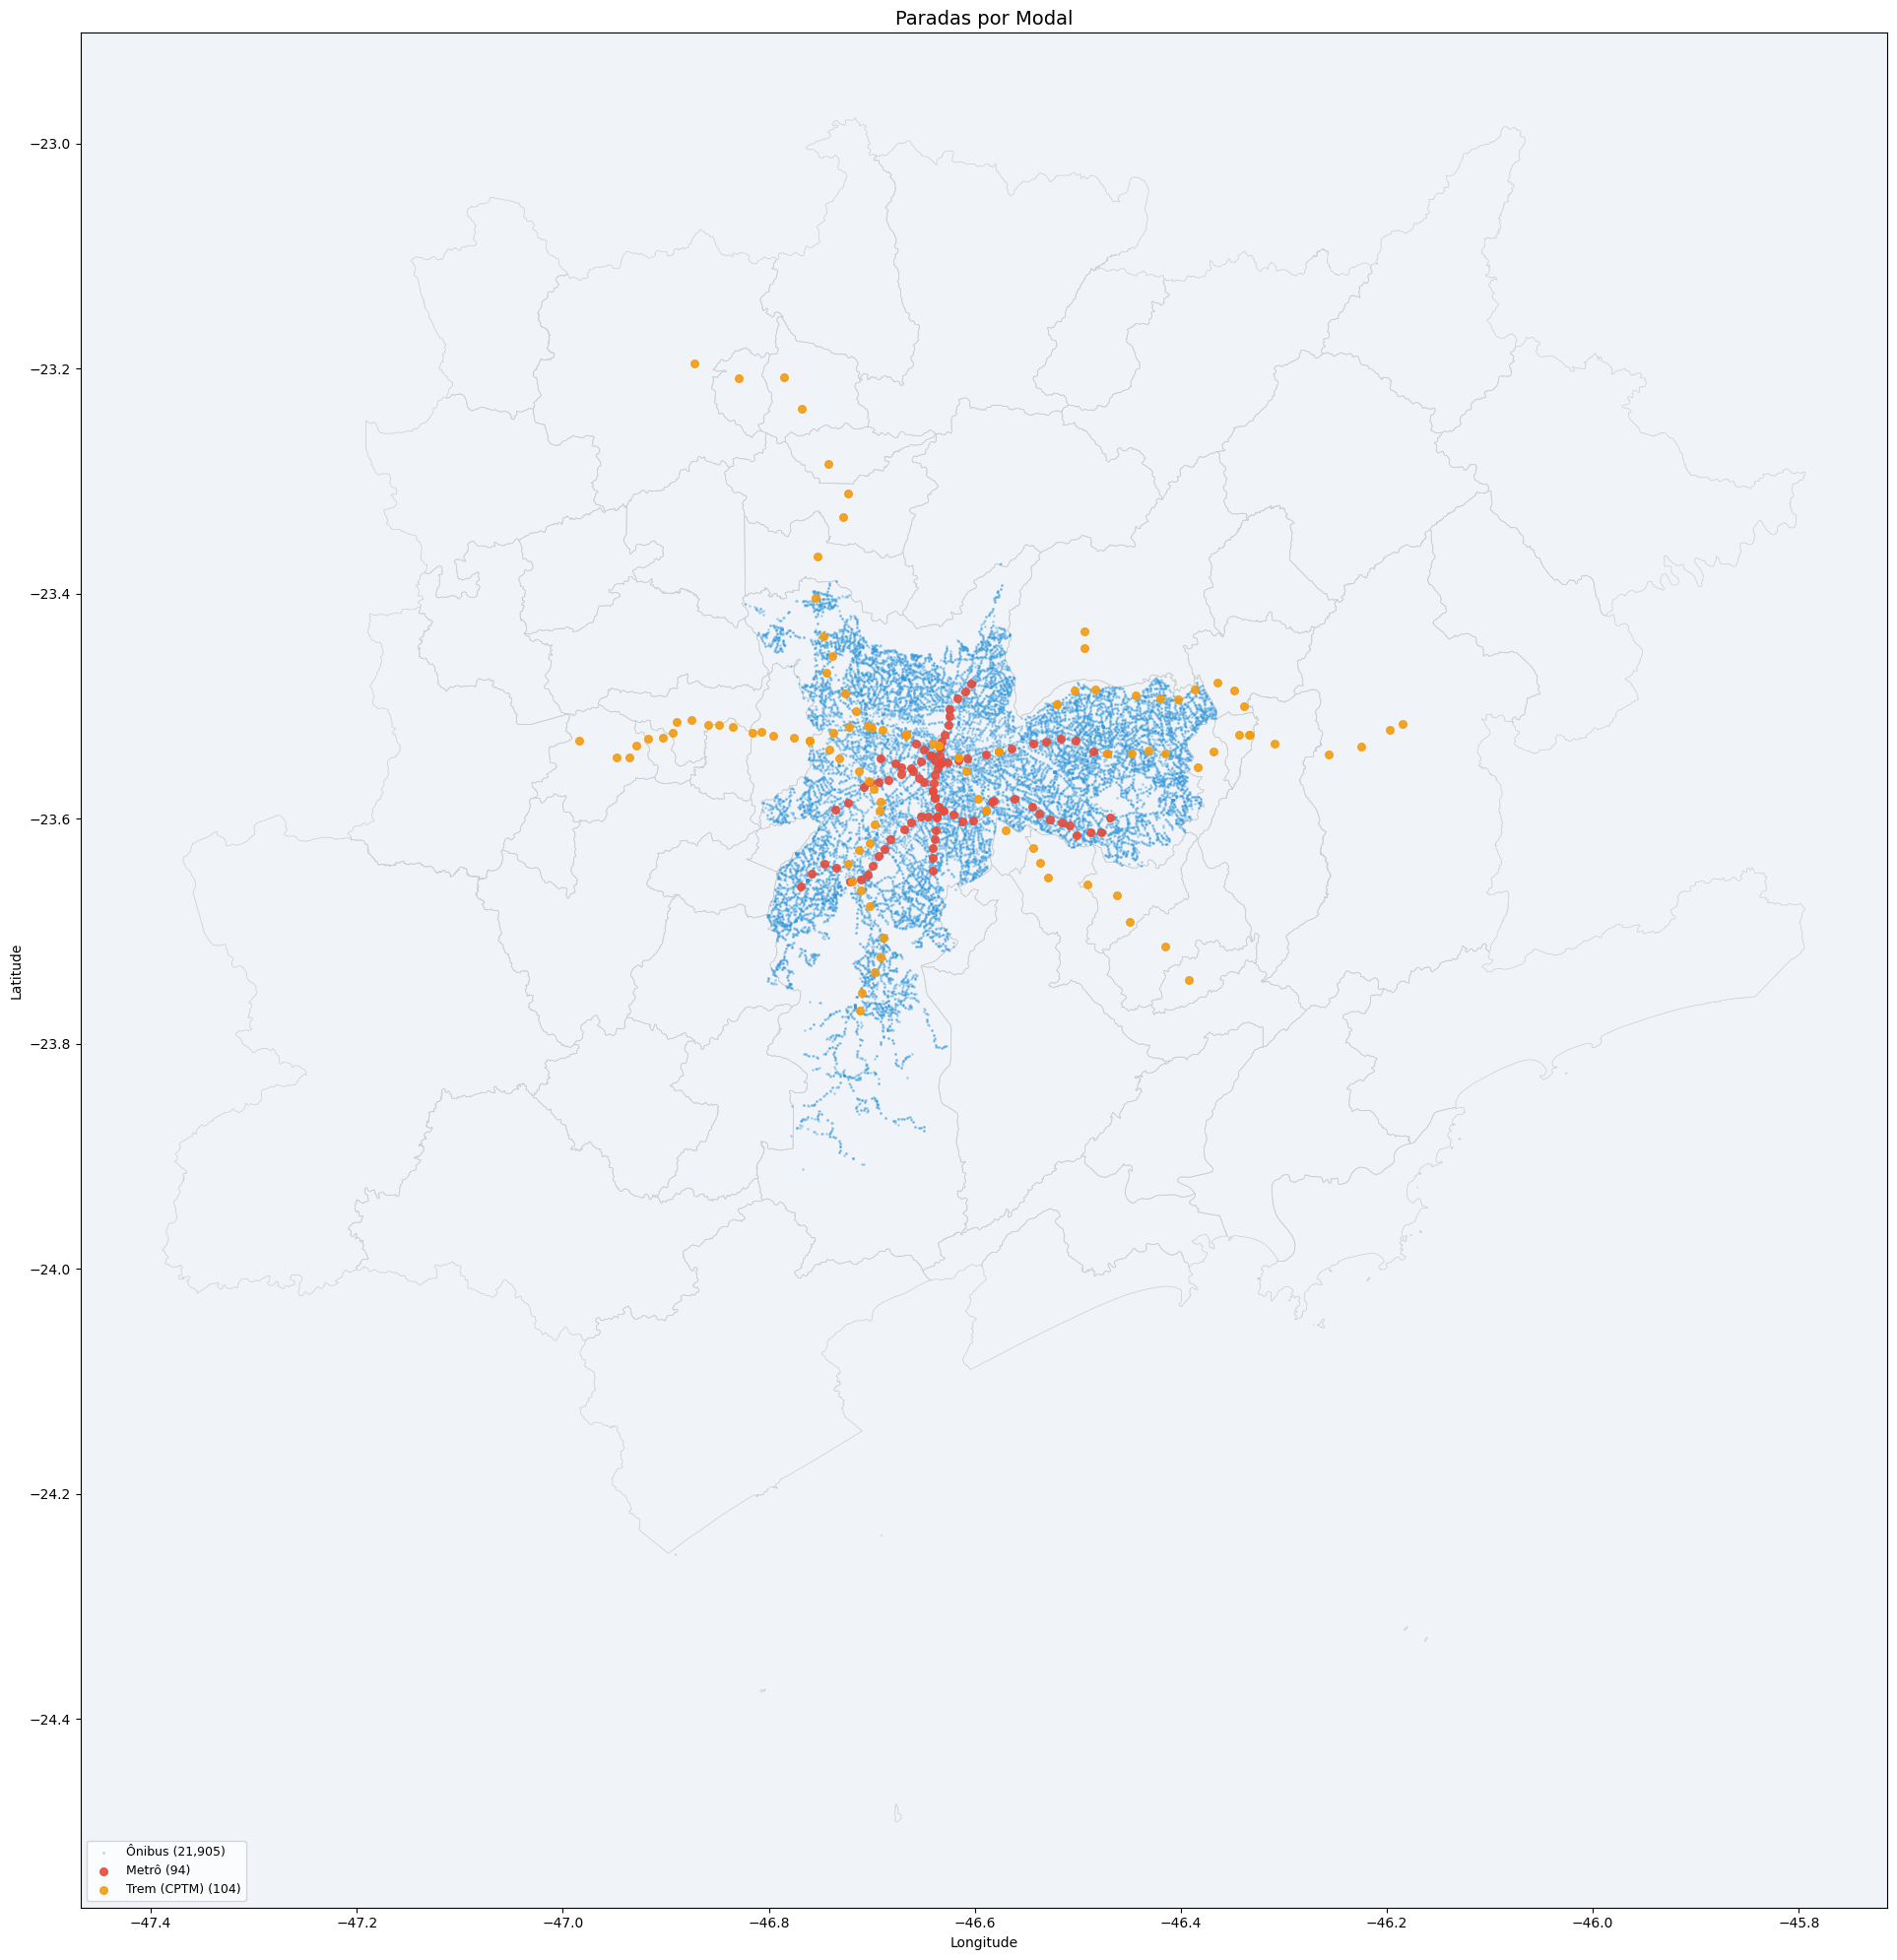

In [20]:
import geopandas as gpd
stops = gtfs['stops']
stop_times = gtfs['stop_times']
trips = gtfs['trips']
routes = gtfs['routes']


# Combinações únicas de (stop_id, trip_id) do stop_times
# drop_duplicates() remove repetições — só precisamos saber QUAIS trips
# passam em QUAIS paradas, não quantas vezes
stop_trip = stop_times[['stop_id', 'trip_id']].drop_duplicates()

# Adicionar route_id (de trips.txt)
stop_route = stop_trip.merge(trips[['trip_id', 'route_id']], on='trip_id')

# Adicionar route_type (de routes.txt)
stop_route = stop_route.merge(routes[['route_id', 'route_type']], on='route_id')

# Para cada parada, pegar o route_type predominante
# Uma parada pode ter ônibus E metrô passando. Usamos first() como simplificação.
# groupby('stop_id') agrupa todas as linhas com mesmo stop_id
stop_modal = stop_route.groupby('stop_id')['route_type'].first().reset_index()

# Juntar de volta com stops pra ter as coordenadas
stops_com_modal = stops.merge(stop_modal, on='stop_id', how='left')

# limites municipais
municipios = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'ibge' / 'SP_Municipios_2024.shp')

# Região Metropolitana de São Paulo (RMSP)
margem = 0.05
lon_min = stops_com_modal['stop_lon'].min() - margem
lon_max = stops_com_modal['stop_lon'].max() + margem
lat_min = stops_com_modal['stop_lat'].min() - margem
lat_max = stops_com_modal['stop_lat'].max() + margem

municipios_recorte = municipios.cx[lon_min:lon_max, lat_min:lat_max]


fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f0f4f8')


municipios_recorte.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#cccccc',
    linewidth=0.5,
    zorder=1
)

# Plotar paradas por cima dos limites municipais
cores = {3: '#3498db', 1: '#e74c3c', 2: '#f39c12'}
nomes = {3: 'Ônibus', 1: 'Metrô', 2: 'Trem (CPTM)'}

for route_type in [3, 1, 2]:
    mask = stops_com_modal['route_type'] == route_type
    qtd = mask.sum()
    ax.scatter(
        stops_com_modal.loc[mask, 'stop_lon'],
        stops_com_modal.loc[mask, 'stop_lat'],
        s=1 if route_type == 3 else 30,
        alpha=0.3 if route_type == 3 else 0.9,
        color=cores[route_type],
        label=f"{nomes[route_type]} ({qtd:,})",
        zorder=2 if route_type == 3 else 3
    )

ax.set_title('Paradas por Modal', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=9, markerscale=1)

plt.tight_layout()
plt.show()

In [21]:
# Buscar São Paulo
sp = municipios[municipios['NM_MUN'].str.contains('São Paulo', case=False)]
print(sp[['NM_MUN', 'CD_MUN']].to_string(index=False))

   NM_MUN  CD_MUN
São Paulo 3550308


##### Cidade de São Paulo

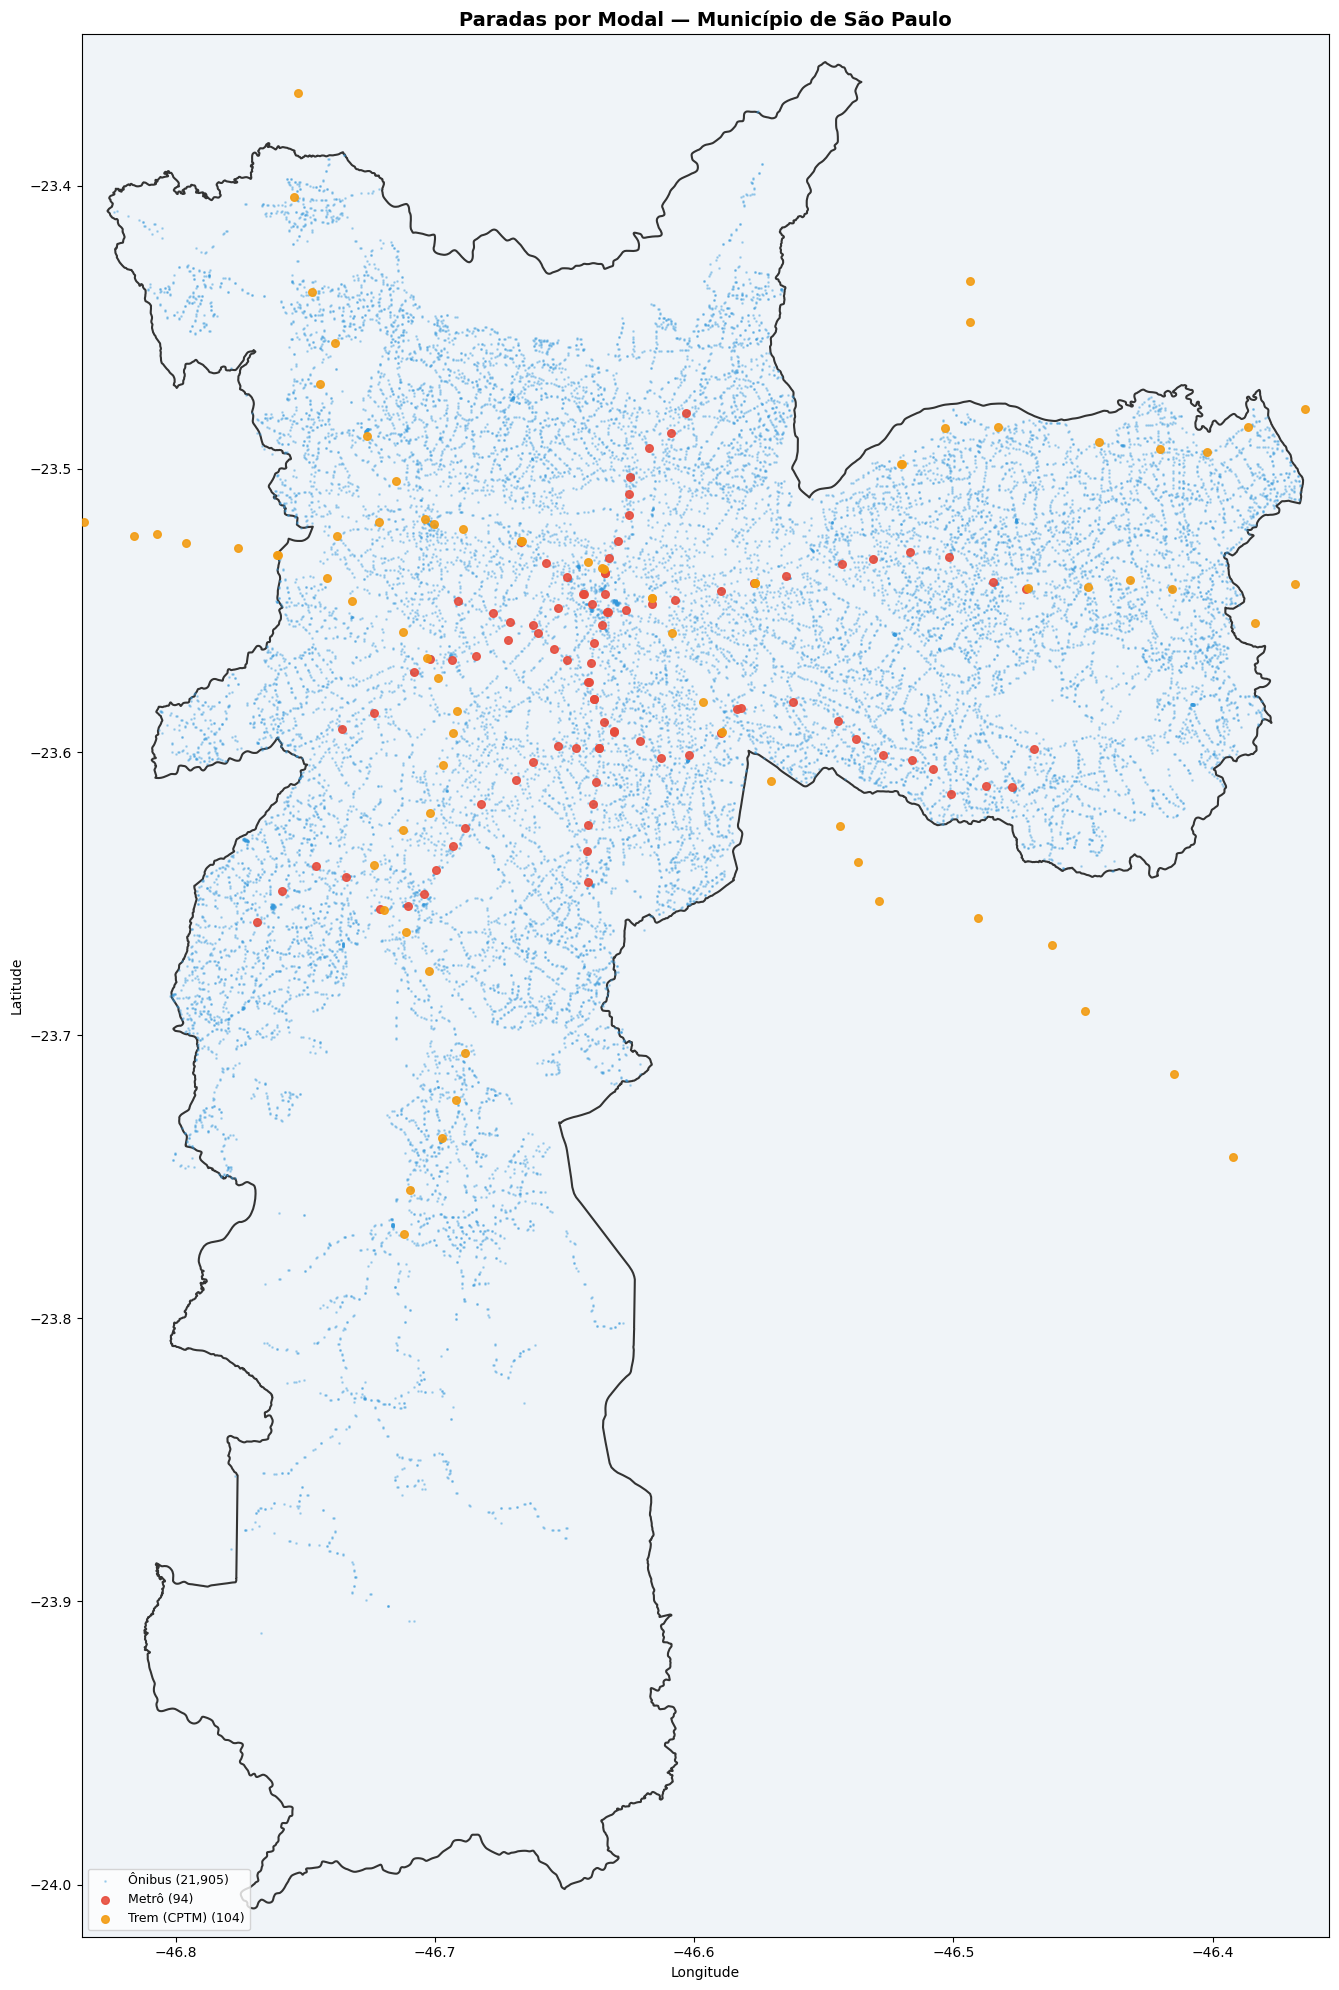

Salvo em: outputs/mapa_paradas_modal_sp.png


In [22]:
stops = gtfs['stops']
stop_times = gtfs['stop_times']
trips = gtfs['trips']
routes = gtfs['routes']

# MODAL DE CADA PARADA
# 1. combinações únicas de (stop_id, trip_id)
stop_trip = stop_times[['stop_id', 'trip_id']].drop_duplicates()

# 2. alldicionar route_id via trips
stop_route = stop_trip.merge(trips[['trip_id', 'route_id']], on='trip_id')

# 3. adicionar route_type via routes
stop_route = stop_route.merge(routes[['route_id', 'route_type']], on='route_id')

# 4. pegar o modal predominante de cada parada
stop_modal = stop_route.groupby('stop_id')['route_type'].first().reset_index()

# 5. juntar com stops pra ter as coordenadas
stops_com_modal = stops.merge(stop_modal, on='stop_id', how='left')

# Limites municipais
municipios = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'ibge' / 'SP_Municipios_2024.shp')

# município de São Paulo
sp_cidade = municipios[municipios['NM_MUN'] == 'São Paulo']

# .total_bounds retorna [lon_min, lat_min, lon_max, lat_max]
# extremos geográficos do polígono de São Paulo
bounds = sp_cidade.total_bounds
margem = 0.01



fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f0f4f8')

# Contorno de São Paulo primeiro
sp_cidade.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#333333',
    linewidth=1.5,
    zorder=1
)

# PParadas por modal
cores = {3: '#3498db', 1: '#e74c3c', 2: '#f39c12'}
nomes = {3: 'Ônibus', 1: 'Metrô', 2: 'Trem (CPTM)'}

for route_type in [3, 1, 2]:
    mask = stops_com_modal['route_type'] == route_type
    qtd = mask.sum()
    ax.scatter(
        stops_com_modal.loc[mask, 'stop_lon'],
        stops_com_modal.loc[mask, 'stop_lat'],
        s=1 if route_type == 3 else 30,
        alpha=0.3 if route_type == 3 else 0.9,
        color=cores[route_type],
        label=f"{nomes[route_type]} ({qtd:,})",
        zorder=2 if route_type == 3 else 3
    )

# Limitar o mapa aos limites de São Paulo
ax.set_xlim(bounds[0] - margem, bounds[2] + margem)
ax.set_ylim(bounds[1] - margem, bounds[3] + margem)

ax.set_title('Paradas por Modal — Município de São Paulo', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=9, markerscale=1)

plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'outputs' / 'mapa_paradas_modal_sp.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Salvo em: outputs/mapa_paradas_modal_sp.png")

### Trips

In [23]:
trips = gtfs['trips']

print(f'Total de viagens: {len(trips):,}')
print(f'\n   Por tipo de serviço:')
for sid, count in trips['service_id'].value_counts().items():
    print(f"      {sid}: {count:,} viagens")

print(f"\n   Por direção:")
print(f"      Ida (0):   {(trips['direction_id'] == 0).sum():,}")
print(f"      Volta (1): {(trips['direction_id'] == 1).sum():,}")

Total de viagens: 2,254

   Por tipo de serviço:
      USD: 1,797 viagens
      U__: 260 viagens
      US_: 197 viagens

   Por direção:
      Ida (0):   1,307
      Volta (1): 947


In [24]:
print((trips["direction_id"] == 0).sum() - (trips["direction_id"] == 1).sum())

# 360 viagens não têm volta definida: linhas circulares ou dados incompletos

360


### Stop Times

In [25]:
print(gtfs['stop_times'].info())

<class 'pandas.DataFrame'>
RangeIndex: 98434 entries, 0 to 98433
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   trip_id         98434 non-null  str  
 1   arrival_time    98434 non-null  str  
 2   departure_time  98434 non-null  str  
 3   stop_id         98434 non-null  int64
 4   stop_sequence   98434 non-null  int64
dtypes: int64(2), str(3)
memory usage: 3.8 MB
None


In [26]:
print(f"   Total de registros: {len(stop_times):,}")

# Quantas paradas cada viagem percorre?
# groupby agrupa por trip_id, .size() conta quantas linhas em cada grupo
paradas_por_viagem = stop_times.groupby('trip_id').size()

print(f"\n   Paradas por viagem:")
print(f"      Média:   {paradas_por_viagem.mean():.1f}")
print(f"      Mediana: {paradas_por_viagem.median():.0f}")
print(f"      Mínimo:  {paradas_por_viagem.min()}")
print(f"      Máximo:  {paradas_por_viagem.max()}")

# Exemplo: ver as paradas de uma viagem específica
exemplo_trip = stop_times[stop_times['trip_id'] == trips.iloc[0]['trip_id']]
exemplo_trip = exemplo_trip.sort_values('stop_sequence')
exemplo_trip = exemplo_trip.merge(gtfs['stops'][['stop_id', 'stop_name']], on='stop_id')

print(f"\n   Exemplo — viagem {trips.iloc[0]['trip_id']}:")
print(f"   Rota: {trips.iloc[0]['route_id']} | Destino: {trips.iloc[0]['trip_headsign']}")
print(exemplo_trip[['stop_sequence', 'arrival_time', 'stop_name']].head(10).to_string(index=False))
print(f"   ... ({len(exemplo_trip)} paradas no total)")

   Total de registros: 98,434

   Paradas por viagem:
      Média:   43.7
      Mediana: 42
      Mínimo:  1
      Máximo:  146

   Exemplo — viagem 1012-10-0:
   Rota: 1012-10 | Destino: Jd. Monte Belo
 stop_sequence arrival_time                         stop_name
             1     07:00:00          Terminal Jardim Britânia
             2     07:01:20 R. Delsuc Alves De Magalhães, 194
             3     07:02:40 R. Delsuc Alves De Magalhães, 538
             4     07:04:00    Estr. Cel. José Gladiador, 262
             5     07:05:20      R. Virgínia Castiglioni, 381
             6     07:06:40                   R. Nestor Gomes
             7     07:08:00           R. Alberto Alvarez, 135
             8     07:09:20          R. Dionísio Bellante, 29
             9     07:10:40      R. João Fernandes Vieira, 92
            10     07:12:00            Estr. De Pirapora, 850
   ... (41 paradas no total)


In [27]:
# Os horários são espaçados de 1min20s — isso é o tempo estimado entre paradas. A viagem 1012-10-0 sai do Terminal Jardim Britânia e faz 41 paradas até o Jd. Monte Belo.
# O mínimo de 1 parada é estranho. E 146 paradas numa única viagem é uma linha bem longa.

### Frequencies

In [28]:
print(gtfs['frequencies'].info())

<class 'pandas.DataFrame'>
RangeIndex: 40146 entries, 0 to 40145
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   trip_id       40146 non-null  str  
 1   start_time    40146 non-null  str  
 2   end_time      40146 non-null  str  
 3   headway_secs  40146 non-null  int64
dtypes: int64(1), str(3)
memory usage: 1.2 MB
None


In [29]:
frequencies = gtfs['frequencies']

print(f"Total de registros: {len(frequencies):,}")
print(f"Trips com frequência definida: {frequencies['trip_id'].nunique():,}")
print()

# Converter headway de segundos pra minutos (mais intuitivo)
frequencies['headway_min'] = frequencies['headway_secs'] / 60

print("Headway (intervalo entre veículos):")
print(f"Mínimo:  {frequencies['headway_min'].min():.0f} min")
print(f"Média:   {frequencies['headway_min'].mean():.1f} min")
print(f"Mediana: {frequencies['headway_min'].median():.0f} min")
print(f"Máximo:  {frequencies['headway_min'].max():.0f} min")
print()

# Extrair a hora de início pra analisar headway ao longo do dia
# start_time é string "HH:MM:SS", pegamos só as horas com str.split
frequencies['hora'] = frequencies['start_time'].str.split(':').str[0].astype(int)

# Calcular headway médio por hora do dia
# Isso revela: nos horários de pico o serviço é mais frequente?
headway_por_hora = frequencies.groupby('hora')['headway_min'].mean()

print("Headway médio por faixa horária:")
for hora, headway in headway_por_hora.items():
    # Criar barra visual proporcional ao headway
    barra = '█' * int(headway / 2)
    print(f"      {hora:02d}h: {headway:5.1f} min  {barra}")

Total de registros: 40,146
Trips com frequência definida: 2,254

Headway (intervalo entre veículos):
Mínimo:  1 min
Média:   21.4 min
Mediana: 15 min
Máximo:  60 min

Headway médio por faixa horária:
      00h:  42.5 min  █████████████████████
      01h:  53.0 min  ██████████████████████████
      02h:  47.2 min  ███████████████████████
      03h:  49.8 min  ████████████████████████
      04h:  33.5 min  ████████████████
      05h:  19.0 min  █████████
      06h:  15.2 min  ███████
      07h:  16.0 min  ████████
      08h:  17.5 min  ████████
      09h:  19.6 min  █████████
      10h:  20.3 min  ██████████
      11h:  20.2 min  ██████████
      12h:  19.3 min  █████████
      13h:  18.5 min  █████████
      14h:  17.8 min  ████████
      15h:  17.3 min  ████████
      16h:  16.5 min  ████████
      17h:  16.9 min  ████████
      18h:  18.3 min  █████████
      19h:  20.2 min  ██████████
      20h:  21.5 min  ██████████
      21h:  22.1 min  ███████████
      22h:  23.5 min  ███████████

- Madrugada (0h-4h): headway de 33-53 min — serviço mínimo
- Pico manhã (5h-7h): cai pra 15-19 min — aumento de oferta
- Entrepico (8h-14h): estável em 17-20 min
- Pico tarde (15h-18h): cai de novo pra 16-17 min
- Noite (19h-23h): sobe gradualmente de 20 a 29 min

**Observação:** O headway segue um padrão claro de oferta vs demanda.
Os picos da manhã (5h-7h) e tarde (15h-18h) têm os menores headways (~16 min), enquanto a madrugada chega a 53 min. A transição é gradual, não abrupta.

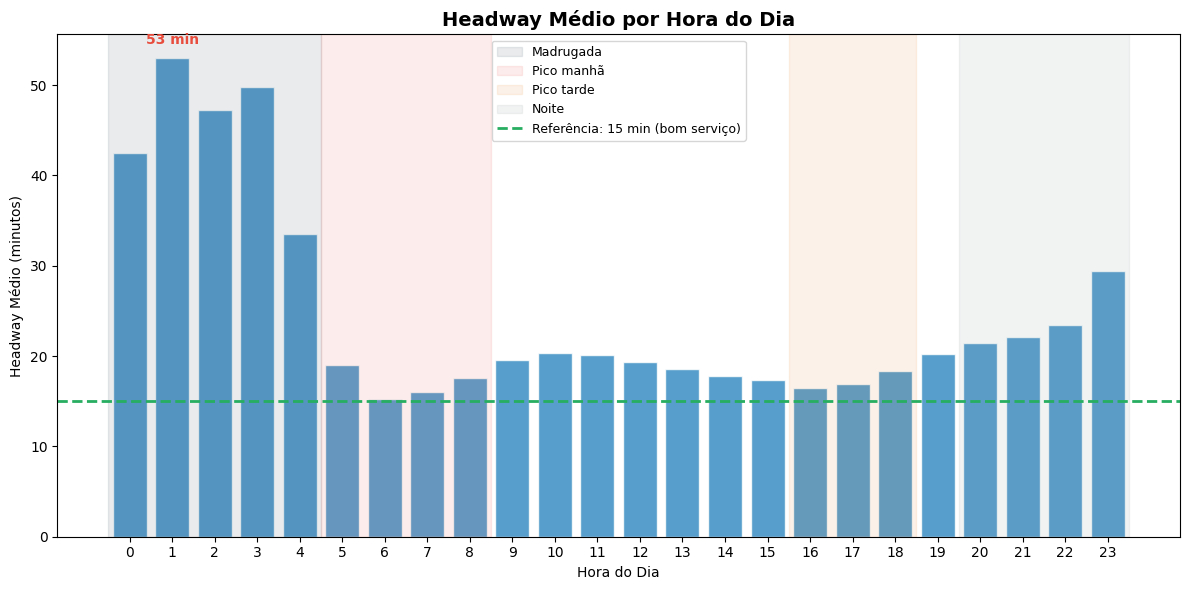

Salvo em: outputs/headway_por_hora.png


In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plotar barras de headway por hora
ax.bar(
    headway_por_hora.index,       # eixo X = hora do dia
    headway_por_hora.values,      # eixo Y = headway médio em minutos
    color='#2e86c1',
    alpha=0.8,
    edgecolor='white'
)

# Adicionar faixas coloridas pra contexto
# axvspan(x_inicio, x_fim) pinta uma faixa vertical
ax.axvspan(-0.5, 4.5, alpha=0.1, color='#2c3e50', label='Madrugada')   # 0h-4h
ax.axvspan(4.5, 8.5, alpha=0.1, color='#e74c3c', label='Pico manhã')   # 5h-8h
ax.axvspan(15.5, 18.5, alpha=0.1, color='#e67e22', label='Pico tarde') # pico tarde
ax.axvspan(19.5, 23.5, alpha=0.1, color='#7f8c8d', label='Noite')      # noite

# Linha de referência: 15 min é considerado um bom headway
ax.axhline(
    y=15, color='#27ae60', linestyle='--', linewidth=2,
    label='Referência: 15 min (bom serviço)'
)

# Anotar os valores extremos diretamente no gráfico
# ax.annotate() coloca um texto apontando pra um ponto específico
ax.annotate(
    f'{headway_por_hora.max():.0f} min',         # texto
    xy=(headway_por_hora.idxmax(), headway_por_hora.max()),  # ponto alvo
    xytext=(0, 10),                                # deslocamento do texto
    textcoords='offset points',                    # unidade do deslocamento
    ha='center', fontweight='bold', color='#e74c3c'
)

ax.set_title('Headway Médio por Hora do Dia', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Headway Médio (minutos)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'outputs' / 'headway_por_hora.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Salvo em: outputs/headway_por_hora.png")

Perguntas:

- Resiliência da rede
  - Identificar impacto de falhas, acidentes, greves...
  - Otimização de rotas (mitigar impacto)

  - métrica: headway (intervalo entre um veículo e o próximo) ?

- Distribuição espacial da oferta
  - correlação entre distância do centro e número de linhas disponíveis por parada
  - número de linhas por paradas
  - distância entre paradas

### Grafo

**Nota metodológica:** O grafo foi construído a partir de stop_times.txt 
(conexões entre paradas consecutivas), não de shapes.txt (geometria viária).
A rede de transporte é definida pela topologia do serviço (onde as pessoas 
embarcam/desembarcam), não pelo trajeto físico nas ruas.

In [31]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import networkx as nx
from collections import Counter

stop_times = gtfs['stop_times']
stops = gtfs['stops']

# 1: Ordenar stop_times por viagem e sequência
# Isso garante que as paradas estão na ordem correta
st_sorted = stop_times.sort_values(['trip_id', 'stop_sequence'])

# 2: Extrair pares de paradas consecutivas
# Para cada viagem, pegamos a lista de paradas em ordem
# e ccria pares (parada_1→parada_2), (parada_2→parada_3), etc.
print("Extraindo conexões entre paradas consecutivas...")

edges_list = []
for trip_id, group in st_sorted.groupby('trip_id'):
    # .values transforma a coluna num array NumPy (mais rápido)
    stop_list = group['stop_id'].values
    for i in range(len(stop_list) - 1):
        edges_list.append((stop_list[i], stop_list[i + 1]))

print(f"   Conexões brutas (com repetições): {len(edges_list):,}")

# 3. Contar quantas vezes cada conexão aparece
# Quanto mais viagens passam por uma conexão, maior o peso
edge_counts = Counter(edges_list)
print(f"   Conexões únicas: {len(edge_counts):,}")

# 4. Criar o grafo
G = nx.Graph()

for (u, v), weight in edge_counts.items():
    # Se a aresta já existe, soma o peso (viagens que passam por ali)
    if G.has_edge(u, v):
        G[u][v]['weight'] += weight
    else:
        G.add_edge(u, v, weight=weight)

# 5.Informações dos nós (nome e coordenadas)
# Isso permitirá plotar o grafo no mapa depois
for _, row in stops.iterrows():
    if row['stop_id'] in G.nodes:
        G.nodes[row['stop_id']]['name'] = row['stop_name']
        G.nodes[row['stop_id']]['lat'] = row['stop_lat']
        G.nodes[row['stop_id']]['lon'] = row['stop_lon']

print(f"\n GRAFO:")
print(f"   Nós (paradas):           {G.number_of_nodes():,}")
print(f"   Arestas (conexões):      {G.number_of_edges():,}")
print(f"   Grau médio:              {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"   Densidade:               {nx.density(G):.6f}")

Extraindo conexões entre paradas consecutivas...
   Conexões brutas (com repetições): 96,180
   Conexões únicas: 29,797

 GRAFO:
   Nós (paradas):           22,103
   Arestas (conexões):      29,558
   Grau médio:              2.67
   Densidade:               0.000121


Grau médio de 2.67, significa que a maioria das paradas conecta com 2 a 3 outras (a anterior e a próxima na rota)

Paradas com grau mais alto são onde várias linhas convergem.

In [33]:

# Analisar componentes conexos

# subgrupo do grafo onde todos os nós se conectam entre si (existe caminho de qualquer nó a qualquer outro).

# Se o grafo tem mais de 1 componente, significa que existem "ilhas" desconectadas — ou seja, não dá pra ir de uma parte a outra da rede sem sair do sistema.

# nx.connected_components(G) retorna um gerador de conjuntos, onde cada conjunto é um componente.

# sorted(..., key=len, reverse=True) ordena do maior pro menor.


# Encontrar todos os componentes conexos
componentes = sorted(nx.connected_components(G), key=len, reverse=True)

print(f"COMPONENTES CONEXOS: {len(componentes)}")
print()

# Mostrar detalhes de cada componente
for i, comp in enumerate(componentes):
    # Pegar nomes de 3 paradas de exemplo deste componente
    exemplos = [G.nodes[n].get('name', str(n)) for n in list(comp)[:3]]
    
    # Calcular qual percentual da rede este componente representa
    percentual = len(comp) / G.number_of_nodes() * 100
    
    print(f"   Componente {i + 1}: {len(comp):,} nós ({percentual:.1f}%)")
    print(f"      Exemplos: {', '.join(exemplos)}")
    print()

# Guardar o maior componente pra usar nas próximas análises
maior_componente = componentes[0]
G_principal = G.subgraph(maior_componente).copy()

print("=" * 60)
print(f"O componente principal contém {len(maior_componente)/G.number_of_nodes()*100:.1f}% da rede")
print(f"Vamos trabalhar com ele daqui pra frente: {G_principal.number_of_nodes():,} nós")

COMPONENTES CONEXOS: 14

   Componente 1: 21,892 nós (99.0%)
      Exemplos: R. Três Corações, 558, R. Mj. Lúcio Dias Ramos, 602, R. Alziro Pinheiro Magalhães, 90

   Componente 2: 42 nós (0.2%)
      Exemplos: Santa Rita, Itapevi, Engenheiro Cardoso

   Componente 3: 28 nós (0.1%)
      Exemplos: Aracaré, Calmon Viana, Itaquaquecetuba

   Componente 4: 23 nós (0.1%)
      Exemplos: Conceição, Jabaquara, São Judas

   Componente 5: 18 nós (0.1%)
      Exemplos: Campo Limpo Paulista, Piqueri, Lapa (linha 7)

   Componente 6: 18 nós (0.1%)
      Exemplos: Tatuapé, República, Carrão

   Componente 7: 17 nós (0.1%)
      Exemplos: Borba Gato, Brooklin, Largo Treze

   Componente 8: 14 nós (0.1%)
      Exemplos: Tamanduateí, Clínicas, Consolação

   Componente 9: 13 nós (0.1%)
      Exemplos: Brás, Tamanduateí, São Caetano

   Componente 10: 11 nós (0.0%)
      Exemplos: R. Prof. Francisco Pinheiro, 864, R. Prof. Francisco Pinheiro, 1181, R. Prof. Francisco Pinheiro, 620

   Componente 11: 

**Achados:** 

- A rede tem 14 componentes conexos. 
- O componente principal (ônibus) contém 99% dos nós. 
- Os 13 menores são linhas de Metrô, CPTM e uma travessia de balsa. Isso revela que no GTFS a integração intermodal não é representada topologicamente — cada modal opera como rede isolada. 
- Uma possível evolução do trabalho seria criar "arestas de integração" entre paradas próximas de modais diferentes.

In [34]:
# Calcular métricas de centralidade

# Centralidade mede a IMPORTÂNCIA de cada nó na rede.
# Existem várias formas de medir, cada uma responde uma pergunta:
#
# 1. DEGREE CENTRALITY
#    Pergunta: "Quantas conexões diretas este nó tem?"
#    Fórmula: grau do nó / (total de nós - 1)
#    Interpretação: paradas com mais linhas convergindo
#    Analogia: pessoa que conhece muita gente numa festa
#
# 2. BETWEENNESS CENTRALITY
#    Pergunta: "Quantos caminhos mínimos passam por este nó?"
#    Interpretação: GARGALOS — se este nó cai, muitos caminhos quebram
#    Analogia: ponte única entre duas ilhas
#    É o mais custoso computacionalmente. Pra grafos grandes,
#    usamos amostragem (k=500) que dá uma boa aproximação.
#
# 3. CLOSENESS CENTRALITY
#    Pergunta: "Quão perto este nó está de todos os outros?"
#    Fórmula: inverso da distância média a todos os outros nós
#    Interpretação: paradas mais ACESSÍVEIS da rede
#    Analogia: morar no centro da cidade vs morar no interior
#
# Referência: https://networkx.org/documentation/stable/reference/algorithms/centrality.html
# ============================================================

print("Calculando métricas de centralidade...")
print(f"   (trabalhando com {G_principal.number_of_nodes():,} nós)")
print()

# DEGREE CENTRALITY — rápido, O(n)
print("   1/3 Degree centrality...")
degree_cent = nx.degree_centrality(G_principal)
print("concluído")

# BETWEENNESS CENTRALITY — lento, por isso usamos amostragem
# k=500 significa: em vez de calcular todos os caminhos mínimos,
# sorteia 500 nós como "origem" e calcula a partir deles.
# É uma aproximação estatística, mas boa o suficiente.
print("   2/3 Betweenness centrality (pode levar 1-2 min)...")
betweenness_cent = nx.betweenness_centrality(
    G_principal,
    k=min(500, len(G_principal.nodes))
)
print("concluído")

# CLOSENESS CENTRALITY
print("   3/3 Closeness centrality...")
closeness_cent = nx.closeness_centrality(G_principal)
print("concluído")

# Consolidar tudo num DataFrame pra facilitar análise
metricas = pd.DataFrame({
    'stop_id': list(G_principal.nodes),
    'stop_name': [G_principal.nodes[n].get('name', '') for n in G_principal.nodes],
    'lat': [G_principal.nodes[n].get('lat', 0) for n in G_principal.nodes],
    'lon': [G_principal.nodes[n].get('lon', 0) for n in G_principal.nodes],
    'degree': [G_principal.degree(n) for n in G_principal.nodes],
    'degree_centrality': [degree_cent[n] for n in G_principal.nodes],
    'betweenness_centrality': [betweenness_cent[n] for n in G_principal.nodes],
    'closeness_centrality': [closeness_cent[n] for n in G_principal.nodes],
})

# Salvar pra não precisar recalcular
metricas.to_csv(REPO_ROOT / 'data' / 'processed' / 'metricas_centralidade.csv', index=False)

print(f"\n Métricas calculadas pra {len(metricas):,} paradas")
print(f"Salvo em: data/processed/metricas_centralidade.csv")

Calculando métricas de centralidade...
   (trabalhando com 21,892 nós)

   1/3 Degree centrality...
concluído
   2/3 Betweenness centrality (pode levar 1-2 min)...
concluído
   3/3 Closeness centrality...
concluído

 Métricas calculadas pra 21,892 paradas
Salvo em: data/processed/metricas_centralidade.csv


In [35]:
#paradas mais importantes da rede
# ============================================================
# Cada métrica de centralidade revela um aspecto diferente:
#   - Degree: onde mais linhas convergem
#   - Betweenness: gargalos (se cair, a rede fragmenta)
#   - Closeness: paradas mais acessíveis a partir de qualquer ponto
#
# nlargest(15, coluna) retorna as 15 maiores linhas daquela coluna.
# É equivalente a: ORDER BY coluna DESC LIMIT 15 em SQL.
# ============================================================

print("DEGREE CENTRALITY (mais conexões diretas)")
print("=" * 70)
top_dc = metricas.nlargest(15, 'degree_centrality')
for i, (_, row) in enumerate(top_dc.iterrows(), 1):
    print(f"   {i:2d}. {row['stop_name'][:40]:<42} grau={row['degree']}")

print()
print("BETWEENNESS CENTRALITY (gargalos da rede)")
print("=" * 70)
top_bc = metricas.nlargest(15, 'betweenness_centrality')
for i, (_, row) in enumerate(top_bc.iterrows(), 1):
    print(f"   {i:2d}. {row['stop_name'][:40]:<42} BC={row['betweenness_centrality']:.6f}")

print()
print("CLOSENESS CENTRALITY (mais acessíveis)")
print("=" * 70)
top_cc = metricas.nlargest(15, 'closeness_centrality')
for i, (_, row) in enumerate(top_cc.iterrows(), 1):
    print(f"   {i:2d}. {row['stop_name'][:40]:<42} CC={row['closeness_centrality']:.6f}")

DEGREE CENTRALITY (mais conexões diretas)
    1. Av. Pe. José Maria                         grau=42
    2. Estr. De Itapecerica, 3646                 grau=30
    3. Parada 2 - Ferreira De Araújo              grau=28
    4. R. Paes Leme, 79                           grau=25
    5. R. Dr. Luiz Aires, 4287                    grau=25
    6. Parada Roberto Simonsen                    grau=24
    7. Estr. Do Campo Limpo, 3410                 grau=24
    8. Parada Vasco Da Gama                       grau=23
    9. R. Dr. Luiz Aires, 4290                    grau=23
   10. R. Pe. José De Jambeiro, 63                grau=23
   11. R. Da Figueira, 249                        grau=22
   12. Estr. Do Campo Limpo, 3401                 grau=22
   13. R. Ezequiel Freire, 489                    grau=21
   14. Terminal A. E. Carvalho                    grau=21
   15. Jairo Góes                                 grau=21

BETWEENNESS CENTRALITY (gargalos da rede)
    1. R. Melo Freire                        

1. **Gargalo crítico:** O corredor Av. Alcântara Machado / Av. Conde de Frontin
   concentra 11 das 15 paradas com maior betweenness. É o principal eixo de 
   conexão Centro ↔ Zona Leste. Vulnerabilidade alta.

2. **Acessibilidade centralizada:** As paradas mais acessíveis estão todas na 
   região da Sé/República. A periferia é estruturalmente mais distante na rede.

3. **Degree vs Betweenness:** As paradas com mais conexões (degree) NÃO são as 
   mesmas dos gargalos (betweenness). Isso indica que conectividade local ≠ 
   importância estrutural pra rede.

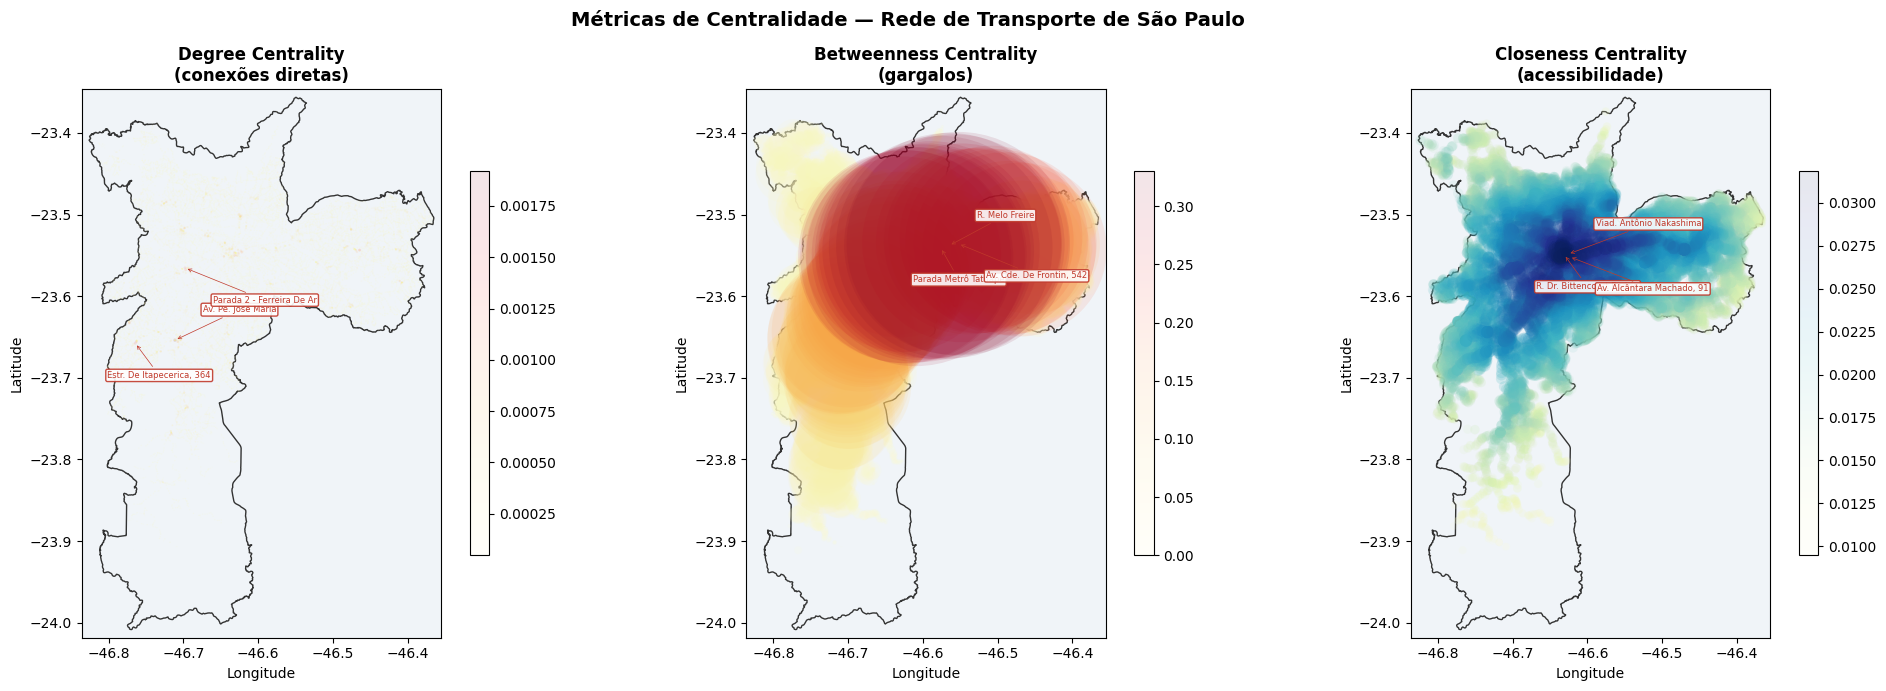

Salvo em: outputs/mapa_centralidades.png


In [ ]:
"""
- Cada ponto = uma parada
- COR do ponto = valor da centralidade (escala de cores)
- TAMANHO do ponto = proporcional à centralidade
"""

sp_cidade = municipios[municipios['NM_MUN'] == 'São Paulo']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'Métricas de Centralidade — Rede de Transporte de São Paulo',
    fontsize=14, fontweight='bold'
)

config = [
    {
        'titulo': 'Degree Centrality\n(conexões diretas)',
        'coluna': 'degree_centrality',
        'cmap': 'YlOrRd',
        'escala': 3000
    },
    {
        'titulo': 'Betweenness Centrality\n(gargalos)',
        'coluna': 'betweenness_centrality',
        'cmap': 'YlOrRd',
        'escala': 80000
    },
    {
        'titulo': 'Closeness Centrality\n(acessibilidade)',
        'coluna': 'closeness_centrality',
        'cmap': 'YlGnBu',
        'escala': 3000
    }
]

for ax, cfg in zip(axes, config):
    ax.set_facecolor('#f0f4f8')

    # Contorno de São Paulo no fundo
    sp_cidade.plot(ax=ax, facecolor='none', edgecolor='#333333', linewidth=1, zorder=1)

    # Valores da centralidade
    vals = metricas[cfg['coluna']].values

    # Ordenar do menor pro maior pra que os vermelhos fiquem por cima
    # argsort() retorna os índices que ordenariam o array do menor pro maior
    ordem = vals.argsort()
    scatter = ax.scatter(
        metricas['lon'].values[ordem],
        metricas['lat'].values[ordem],
        c=vals[ordem],
        cmap=cfg['cmap'],
        s=vals[ordem] * cfg['escala'] + 0.5,
        alpha=0.1,
        edgecolors='none',
        zorder=2
    )

    plt.colorbar(scatter, ax=ax, shrink=0.7)

    # Anotar top 3 com deslocamentos alternados pra não sobrepor
    # Cada rótulo vai pra uma direção diferente: cima-direita, baixo-esquerda, baixo-direita
    top3 = metricas.nlargest(3, cfg['coluna'])
    deslocamentos = [(20, 20), (-20, -25), (20, -25)]
    for (_, row), desloc in zip(top3.iterrows(), deslocamentos):
        ax.annotate(
            row['stop_name'][:25],
            (row['lon'], row['lat']),
            fontsize=6,
            color='#c0392b',
            textcoords='offset points',
            xytext=desloc,
            arrowprops=dict(
                arrowstyle='->',
                color='#c0392b',
                linewidth=0.5
            ),
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                alpha=0.9,
                edgecolor='#c0392b'
            )
        )

    # Limitar ao município de São Paulo
    bounds = sp_cidade.total_bounds
    ax.set_xlim(bounds[0] - 0.01, bounds[2] + 0.01)
    ax.set_ylim(bounds[1] - 0.01, bounds[3] + 0.01)

    ax.set_title(cfg['titulo'], fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig(
    str(REPO_ROOT / 'outputs' / 'mapa_centralidades.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Salvo em: outputs/mapa_centralidades.png")